In [0]:
import numpy as np
import pandas as pd

# Simulate 500 applicant ages (assume ages follow a normal distribution)
applicant_ages = np.random.normal(loc=35, scale=10, size=500)

# Simulate loan amounts (positively skewed, so use exponential)
loan_amounts = np.random.exponential(scale=15000, size=500)

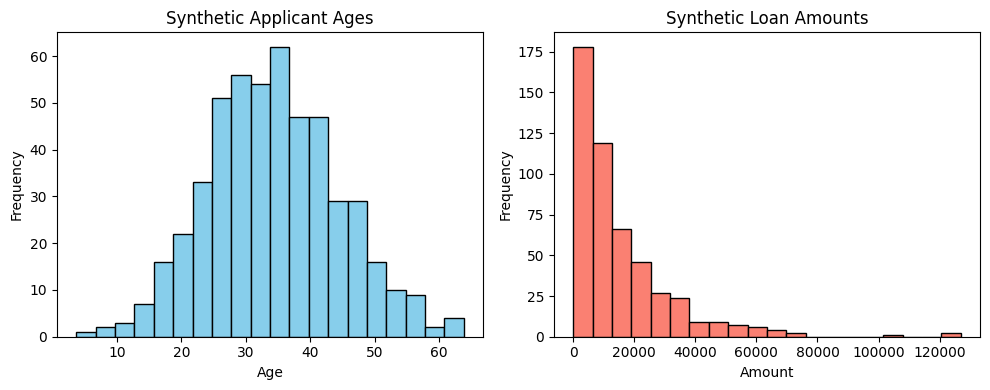

In [0]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Age distribution
axes[0].hist(applicant_ages, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Synthetic Applicant Ages')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Loan amount distribution
axes[1].hist(loan_amounts, bins=20, color='salmon', edgecolor='black')
axes[1].set_title('Synthetic Loan Amounts')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig("applicant_ages.png")

In [0]:
import pandas as pd

# Simulated real applicant data
data = pd.DataFrame({
    'credit_score': [720, 690, 680, 710, 740],
    'loan_purpose': ['auto', 'home', 'education', 'business', 'personal']
})

# Create a bootstrap sample of 10 applicants
bootstrap_sample = data.sample(n=10, replace=True)

In [0]:
data

,credit_score,loan_purpose
0,720,auto
1,690,home
2,680,education
3,710,business
4,740,personal


In [0]:
bootstrap_sample

,credit_score,loan_purpose
4,740,personal
2,680,education
2,680,education
0,720,auto
1,690,home
3,710,business
3,710,business
2,680,education
2,680,education
2,680,education


In [0]:
# Shuffle loan purposes only
shuffled_purposes = data['loan_purpose'].sample(frac=1).reset_index(drop=True)

In [0]:
# Simulate variation in monthly income by injecting noise
base_income = np.array([4000, 4500, 4800, 5200, 6000])
noisy_income = base_income + np.random.normal(loc=0, scale=300, size=len(base_income))

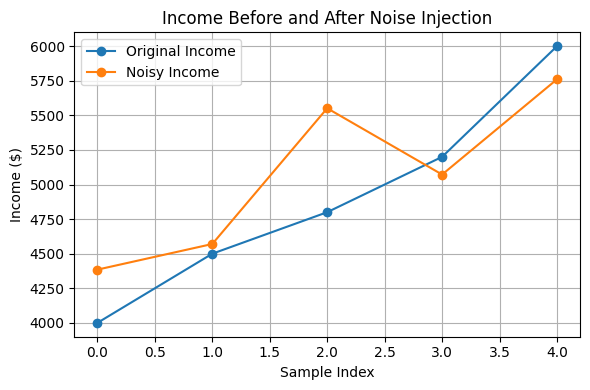

In [0]:
plt.figure(figsize=(6, 4))
plt.plot(base_income, label='Original Income', marker='o')
plt.plot(noisy_income, label='Noisy Income', marker='o')
plt.title('Income Before and After Noise Injection')
plt.xlabel('Sample Index')
plt.ylabel('Income ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('noise_injection.png')

In [0]:
%pip install faker
from faker import Faker
import random

fake = Faker()
customers = []

for _ in range(10):
    age = random.randint(20, 75)
    income = round(np.random.normal(loc=50000 + age * 300, scale=5000), 2)
    premium = round(income * random.uniform(0.05, 0.15), 2)

    customer = {
        'name': fake.name(),
        'email': fake.email(),
        'age': age,
        'annual_income': income,
        'policy_type': random.choice(['health', 'auto', 'home']),
        'premium_estimate': premium
    }
    customers.append(customer)

df = pd.DataFrame(customers)
df

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


,name,email,age,annual_income,policy_type,premium_estimate
0,Joyce Jones,schneidermegan@example.org,68,76139.47,health,5421.99
1,Amanda Walker,jeffreymedina@example.org,23,44128.50,auto,6417.88
2,Melissa Ferguson,mcollins@example.net,67,70419.65,auto,4628.64
3,Rachael Johnson,olsonshane@example.net,36,60642.48,home,8219.54
4,William Howard,rebeccasanders@example.org,35,54882.76,health,7041.26
5,Colleen Johnson,philip19@example.org,63,68937.54,home,4720.97
6,Heidi Johnson,andrewthomas@example.org,68,69790.39,home,6938.43
7,William Chapman,stephaniehuffman@example.com,50,62577.58,auto,3266.98
8,Andrew Rollins,fkennedy@example.net,25,60704.86,health,8425.05
9,Brenda Nguyen,michael93@example.net,47,65011.24,auto,7491.14


## Section 3 : Probabilistic

In [0]:
%pip install copulas
import pandas as pd
import numpy as np
from copulas.multivariate import GaussianMultivariate

# Sample real dataset (could be anonymized or simulated)
real_data = pd.DataFrame({
    'age': np.random.normal(40, 10, 500),
    'income': np.random.normal(60000, 15000, 500),
    'credit_score': np.random.normal(700, 50, 500)
})

# Fit the Gaussian copula model
model = GaussianMultivariate()
model.fit(real_data)

# Generate synthetic data
synthetic_data = model.sample(500)

# Compare correlation structure
print("Real Data Correlation:\n", real_data.corr())
print("\nSynthetic Data Correlation:\n", synthetic_data.corr())


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


/databricks/python/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:5999: RuntimeWarning: divide by zero encountered in divide
  return c**2 / (c**2 - n**2)
/databricks/python/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:5999: RuntimeWarning: divide by zero encountered in divide
  return c**2 / (c**2 - n**2)
/databricks/python/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:719: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/databricks/python/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/databricks/python/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:5999: RuntimeWarning: divide by zero encountered in divide
  return c**2 / (c**2 - n**2)


Real Data Correlation:
                    age    income  credit_score
age           1.000000  0.064771     -0.054547
income        0.064771  1.000000      0.061082
credit_score -0.054547  0.061082      1.000000

Synthetic Data Correlation:
                    age    income  credit_score
age           1.000000  0.051292     -0.089987
income        0.051292  1.000000      0.106147
credit_score -0.089987  0.106147      1.000000


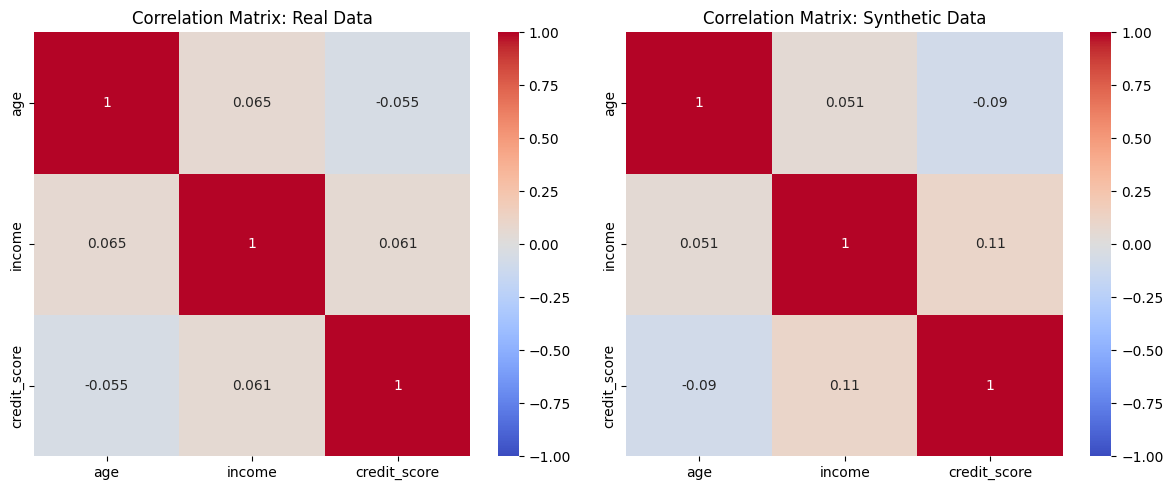

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Real data correlation matrix
sns.heatmap(real_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation Matrix: Real Data')

# Synthetic data correlation matrix
sns.heatmap(synthetic_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation Matrix: Synthetic Data')

plt.tight_layout()
plt.show()
plt.savefig("copula_correlation_comparison.png", dpi=300, bbox_inches='tight')
plt.close()


In [0]:
real_data.head()

,age,income,credit_score
0,35.793742,71024.981118,653.052635
1,22.037269,63924.716170,658.405664
2,42.090685,79350.434695,643.005407
3,48.417705,71824.814047,734.991041
4,30.222854,61800.287231,735.086177


In [0]:
synthetic_data.head()

,age,income,credit_score
0,22.558099,49513.880959,727.537692
1,27.621732,58631.770379,716.883756
2,42.431013,42585.819234,728.887848
3,36.158976,93222.731918,729.043553
4,43.140851,50188.317135,641.289056


## Section 4: ML based using Synthetic Data Vault (SDV)

In [0]:
%pip install sdv

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from pyspark.sql import SparkSession
from sdv.single_table import CTGANSynthesizer, GaussianCopulaSynthesizer
from sdv.metadata import Metadata

spark = SparkSession.builder.appName("Adult Census Analysis").getOrCreate()
df = spark.read.table('damo630_modules_data.module4_data.adult_census')
data = df.toPandas()

# Column names from adult.names file
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
    'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]

In [0]:
real_data = data.sample(n=2000, random_state=42).reset_index(drop=True)
real_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,27,Private,160178,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,38,United-States,<=50K
1,45,State-gov,50567,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
2,29,Private,185908,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Black,Male,0,0,55,United-States,>50K
3,30,Private,190040,Bachelors,13,Never-married,Machine-op-inspct,Not-in-family,White,Female,0,0,40,United-States,<=50K
4,29,Self-emp-not-inc,189346,Some-college,10,Divorced,Craft-repair,Not-in-family,White,Male,2202,0,50,United-States,<=50K


In [0]:
metadata = Metadata.detect_from_dataframe(real_data)
# metadata.save_to_json('metadata.json')

In [0]:
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(real_data)
synthetic_data = synthesizer.sample(2000)
synthetic_data.head()

/local_disk0/.ephemeral_nfs/envs/pythonEnv-7409cfaa-3a94-4854-9d9d-71b12063b6c2/lib/python3.11/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,44,State-gov,157303,Assoc-voc,11,Married-civ-spouse,Prof-specialty,Wife,White,Male,0,1806,42,United-States,>50K
1,48,Private,187490,HS-grad,9,Never-married,Machine-op-inspct,Husband,Black,Male,0,2135,42,United-States,<=50K
2,27,Private,182503,Some-college,9,Married-civ-spouse,Farming-fishing,Husband,White,Female,0,2255,42,United-States,<=50K
3,25,Private,99249,HS-grad,13,Married-civ-spouse,Prof-specialty,Not-in-family,White,Male,1,1769,42,United-States,<=50K
4,36,?,298169,Bachelors,8,Never-married,?,Not-in-family,White,Male,231,2411,42,United-States,<=50K


In [0]:
from sdv.evaluation.single_table import run_diagnostic
diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 1110.19it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 297.38it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [0]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 1075.32it/s]|
Column Shapes Score: 83.95%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 293.70it/s]|
Column Pair Trends Score: 74.95%

Overall Score (Average): 79.45%



In [0]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    column_name='occupation',
    metadata=metadata
)

fig.show()